# Business Case:-
**No-Churn wants to explore possibility of Machine Learning to help with following use cases to retain competitive edge in the industry.**

In [1]:
## importing libraries
import numpy as np                  # importing numpy for mathematical/numerical analysis
import pandas as pd                 # importing pandas for analyzing, manipulation or claeaning data
import seaborn as sns               # importing seaborn for visualize the data
import matplotlib.pyplot as plt     # importing matplotlib for visualize and ploting the statistical data
import warnings                     # importing warnings to ignore any type of warnings
warnings.filterwarnings('ignore')   # filter warnings to ignore
import mysql.connector              # to connect the sql server to fetch the dataset

In [2]:
# making a connection by using credentials
conn = mysql.connector.connect(
    host= '18.136.157.135',
    user= 'dm_team3',
    password="DM!$!Team!27@9!20&",
    database="project_telecom"
)

In [3]:
project = pd.read_sql_query("show tables",conn)
print(project)

  Tables_in_project_telecom
0        telecom_churn_data


In [4]:
query = "SELECT * FROM telecom_churn_data;"

# Load into pandas DataFrame
data = pd.read_sql(query, conn)

In [5]:
# Close Connection
conn.close()

In [6]:
# to display the all columns
pd.set_option('display.max_columns', None)
data

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0


In [7]:
# Save dataset as CSV
data.to_csv("no_churn_telecom.csv", index=False)

print("Dataset saved successfully!")


Dataset saved successfully!


## Domain Analysis

# No-Churn Telecom Domain Analysis

No-Churn Telecom is an established Telecom operator in Europe with more than a decade in Business. Due to new players in the market, telecom industry has become very competitive and retaining customers becoming a challenge.  

In spite of No-Churn initiatives of reducing tariffs and promoting more offers, the churn rate (percentage of customers migrating to competitors) is well above 10%.

## PROJECT GOAL

Help No-Churn with their use cases with ML

1. Understanding the variables that are influencing the customers to migrate.  
2. Creating Churn risk scores that can be indicative to drive retention campaigns.  
3. Introduce new predicting variable “CHURN-FLAG” with values YES(1) or NO(0) so that email campaigns with lucrative offers can be targeted to Churn YES customers.

It help to identify possible CHURN-FLAG YES customers and provide more attention in customer touch point areas, including customer care support, request fulfilment, auto categorizing tickets as high priority for quick resolutions any questions they may have etc.,

## Column Descriptions

- **customer_id** – Unique identification number assigned to each customer.  
- **telecom_partner** – Name of the telecom service provider the customer is using.  
- **gender** – Gender of the customer (Male/Female/Other).  
- **age** – Age of the customer in years  
- **state** – State where the customer resides.  
- **city** – City where the customer resides.  
- **pincode** – Postal code of the customer’s residential area.  
- **date_of_registration** – Date when the customer registered or joined the telecom service.  
- **num_dependents** – Number of dependents financially supported by the customer.  
- **estimated_salary** – Estimated annual income of the customer.  
- **calls_made** – Total number of calls made by the customer.  
- **sms_sent** – Total number of SMS messages sent by the customer.  
- **data_used** – Total internet data consumed by the customer (likely in MB/GB).  
- **churn** – Indicates whether the customer left the telecom service (0 = No churn, 1 = Churn).  


## Basic Checks

In [8]:
data.head() # first five rows

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [9]:
data.tail()     # Last five rows 

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0
243552,243553,BSNL,F,37,Telangana,Hyderabad,139086,2023-05-04,0,144297,61,7,3384,0


In [10]:
data.shape

(243553, 14)

In [11]:
# information about the columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [12]:
data.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [13]:
# values count of target variable

data.churn.value_counts()

churn
0    194726
1     48827
Name: count, dtype: int64

In [14]:
# Statistical analysis

data.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [15]:
data.describe(include = 'O')

,telecom_partner,gender,state,city,date_of_registration
count,243553,243553,243553,243553,243553
unique,4,2,28,6,1220
top,Reliance Jio,M,Uttarakhand,Chennai,2020-01-01
freq,61123,145977,8856,40749,200


## Insights:-

* The dataset includes 243,553 customers with an average age of 46 years and an average salary of 85,021, and most customers have 2 dependents.
* On average, customers make 49 calls, send 24 SMS, and use about 4993 MB of data, though **some negative values indicate possible data issues**.
* The churn rate is around 20%, meaning most customers are retained.
* Most customers are male, associated with **Reliance Jio**, mainly from Uttarakhand, and Chennai is the most common city.

## Exploratory Data Analysis

In [16]:
data.sample(5)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
164859,164860,BSNL,F,73,Chhattisgarh,Delhi,716515,2022-04-05,3,72941,65,-2,9853,0
89078,89079,Reliance Jio,M,57,Tripura,Mumbai,453020,2021-03-21,2,118142,30,6,6620,0
73279,73280,Airtel,F,62,Punjab,Kolkata,711659,2021-01-01,3,95753,64,34,3794,0
116649,116650,BSNL,M,41,Manipur,Kolkata,581422,2021-08-06,4,66490,17,16,7946,1
82633,82634,BSNL,F,38,Goa,Delhi,819768,2021-02-17,1,61235,71,7,338,0


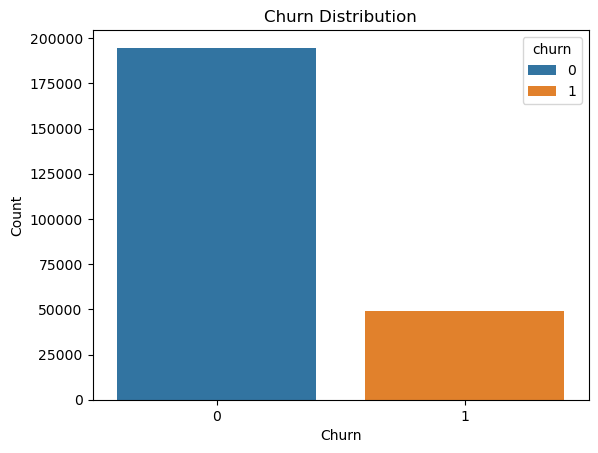

In [17]:
# checking that data is balanced or not
sns.countplot(data=data, x='churn', hue='churn')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Insights:-
* As we can see the above plot there is a huge difference between the both classes, its a highly imbalanced

<Axes: xlabel='telecom_partner', ylabel='count'>

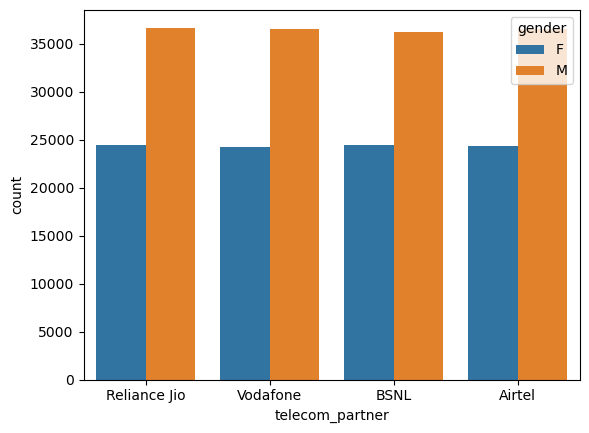

In [18]:
# checking the of each telecom partner
sns.countplot(x= data['telecom_partner'],hue = data['gender'])

### Insights:- 
* Most of the customers are male in every telecom partner.

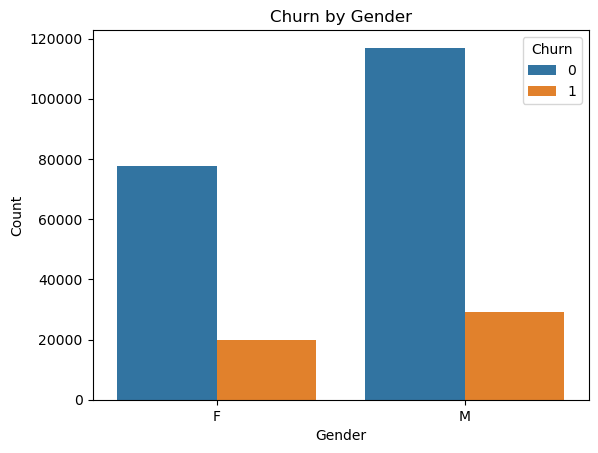

In [19]:
## checking count of gender with churn
sns.countplot(data=data, x='gender', hue='churn')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

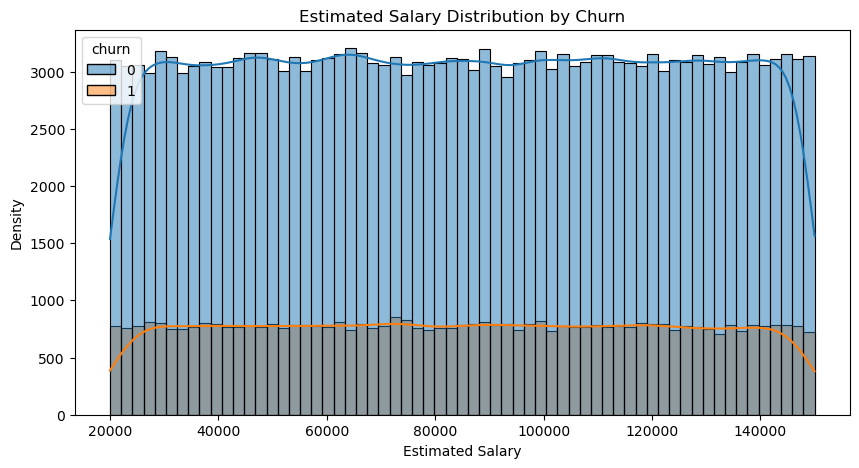

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='estimated_salary', hue='churn', kde=True)
plt.title('Estimated Salary Distribution by Churn')
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.show()

### Insights:-
* The salary pattern is almost the same for churned and non-churned customers.
* Customers are evenly distributed across all salary ranges.
* Non-churn customers are higher because they are the majority.
* Estimated salary does not strongly influence churn.

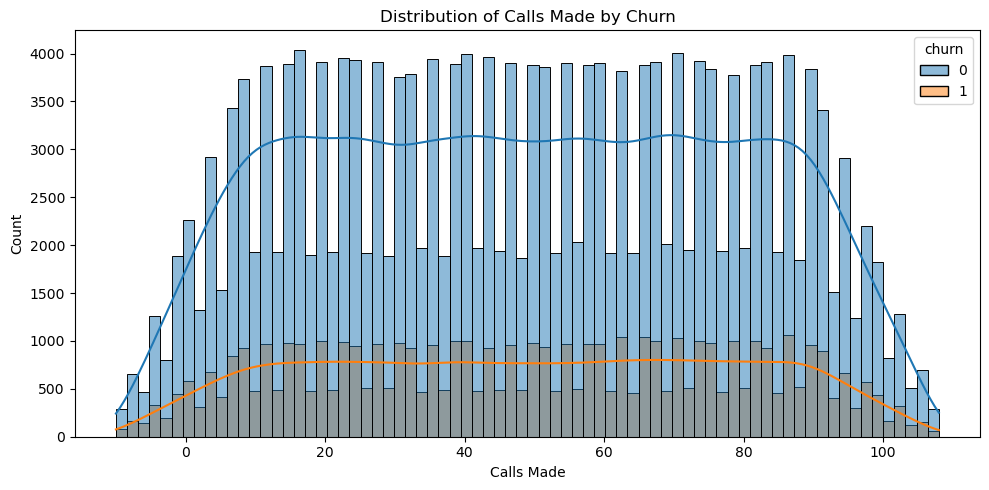

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='calls_made', hue='churn', kde=True)
plt.title('Distribution of Calls Made by Churn')
plt.xlabel('Calls Made')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Insights:-

* The distribution of calls made is very similar for **churned and non-churned customers**.
* Most customers make between **20** and **90** calls.
* Non-churn customers are higher in count because they are the **majority**.
* Calls made is not a strong factor in distinguishing churn.

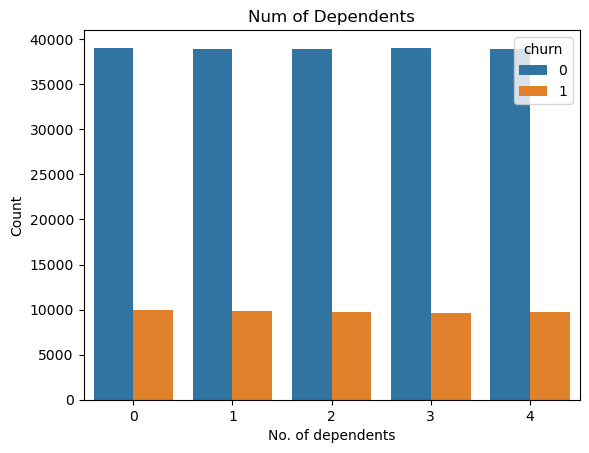

In [22]:
# checking no. of dependents with thier churn
sns.countplot(data=data, x='num_dependents', hue='churn')
plt.title('Num of Dependents')
plt.xlabel('No. of dependents')
plt.ylabel('Count')
plt.show()

In [23]:
data.head(2)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0


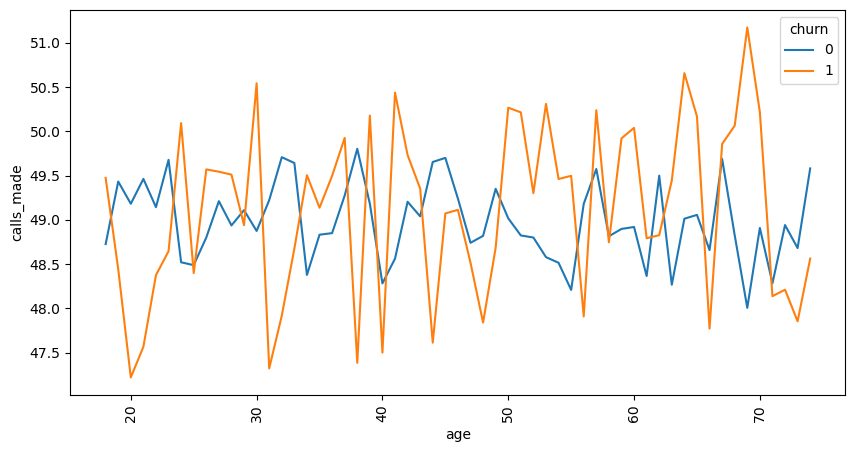

In [24]:
# age vs calls_made
plt.figure(figsize=(10,5))
sns.lineplot(data=data, x='age', y = 'calls_made',hue='churn',ci=None)
plt.xticks(rotation = 90)
plt.show()

### Insights:-
* The number of calls made is almost similar across all age groups for both churned and non-churned customers.
* Churn customers show slightly more fluctuation in call usage.
* There is no clear age group where calls are significantly higher or lower.
* Overall, calls made does not show a strong relationship with churn based on age

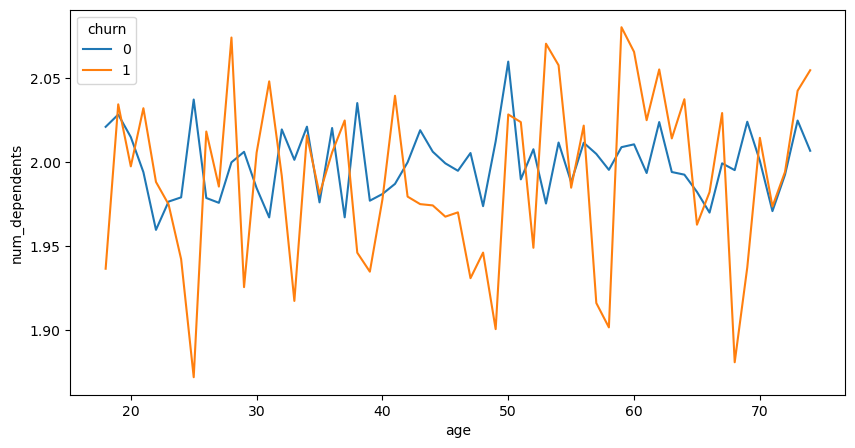

In [25]:
# age vs num_dependents
plt.figure(figsize=(10,5))
sns.lineplot(data=data, x='age', y = 'num_dependents',hue='churn',ci=None)
plt.show()

### Insight:-

* There is no clear age group where **dependents are higher for churn customers**.
* **Number of dependents does not show a strong impact on churn**.

In [26]:
data

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0


## Overall Insights:-
* The dataset is **highly imbalanced**, with far more non-churn customers than churn customers.
* Most customers are **male** across all telecom partners.
* Estimated salary has **no strong impact on churn**, as both groups follow a similar pattern.
* Calls made also does not clearly differentiate churn customers, and usage is similar for both groups and across age.
* Number of dependents shows **no noticeable relationship** with churn.
* **Overall, these features have low influence on churn.**

# Data Preprocessing

In [27]:
# checking for null values
data.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [28]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

In [29]:
## I'm dropping columns which are not used for model building
data.drop(columns=['customer_id','state','city'],axis=1,inplace=True)

In [30]:
data.head(3)

,telecom_partner,gender,age,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,Reliance Jio,F,25,755597,2020-01-01,4,124962,44,45,-361,0
1,Reliance Jio,F,55,125926,2020-01-01,2,130556,62,39,5973,0
2,Vodafone,F,57,423976,2020-01-01,0,148828,49,24,193,1


In [31]:
## checking negative values call_made,sms_sent,data_used

col = ['calls_made', 'sms_sent', 'data_used']
for i in col:
    negative_count = (data[i] < 0).sum()       # total sum of negative values in each columns
    print(f"{i}: {negative_count} negative values")      # printing the total negative values in each columns

calls_made: 6713 negative values
sms_sent: 7375 negative values
data_used: 6050 negative values


### Insights:- 
* *Negative values are seems like an invalid values in data_used,call_made and sms_sent*
* *So, it should be replaced by their median*

In [32]:
# Replace negative values with median

for i in col:
    median_val = data.loc[data[i] >= 0, i].median()
    data.loc[data[i] < 0, i] = median_val


In [33]:
## verifying that negative values are replaced or not

col = ['calls_made', 'sms_sent', 'data_used']
for i in col:
    negative_count = (data[i] < 0).sum()
    print(f"{i}: {negative_count} negative values")

calls_made: 0 negative values
sms_sent: 0 negative values
data_used: 0 negative values


In [34]:
data.telecom_partner.unique()

array(['Reliance Jio', 'Vodafone', 'BSNL', 'Airtel'], dtype=object)

In [35]:
# replacing categorical columns by one-hot encoding

data = pd.get_dummies(data, columns=['telecom_partner'], drop_first=True)

In [36]:
data.select_dtypes(include='bool').columns

Index(['telecom_partner_BSNL', 'telecom_partner_Reliance Jio',
       'telecom_partner_Vodafone'],
      dtype='object')

In [37]:
# Convert bool to int
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [38]:
# fetching year from date_of_registration

data['date_of_registration'] = pd.to_datetime(data['date_of_registration'])
data['registration_year'] = data['date_of_registration'].dt.year

In [39]:
# I'm droping the date_of_registration because no longer needed 
data.drop('date_of_registration',axis=1,inplace=True)

In [40]:
# use map in gender columns

data['gender'] = data['gender'].map({'F': 0, 'M': 1})


In [41]:
data.gender.value_counts()

gender
1    145977
0     97576
Name: count, dtype: int64

In [42]:
# droping pincode columns as it not required for model building
data.drop('pincode',axis=1,inplace=True)

In [43]:
data.sample(5)

,gender,age,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone,registration_year
132377,0,48,3,132101,14,43,4409,0,0,1,0,2021
24518,0,59,0,124622,60,4,5112,0,0,1,0,2020
243211,0,58,2,64809,92,32,238,0,0,0,0,2023
68688,0,41,4,82100,89,44,4632,0,0,1,0,2020
237251,0,70,2,132854,10,33,2724,0,0,0,1,2023


## Check for Outliers

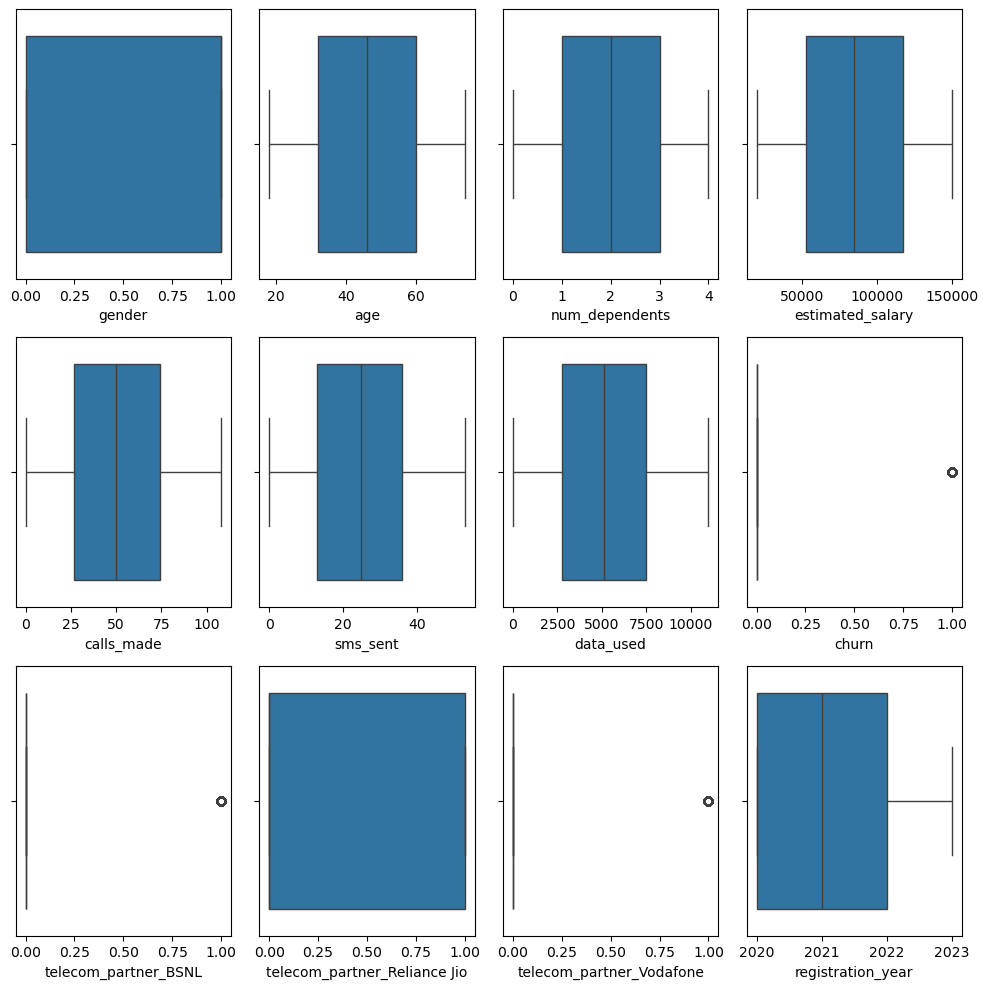

In [44]:
plt.figure(figsize=(10,10))
plotnumber = 1
for i in data.columns:
    plt.subplot(3,4,plotnumber)
    sns.boxplot(x=data[i])
    plotnumber+=1
plt.tight_layout()
plt.show()

### Insights:-
* **There is no outlier in our data**

# Feature Engineering

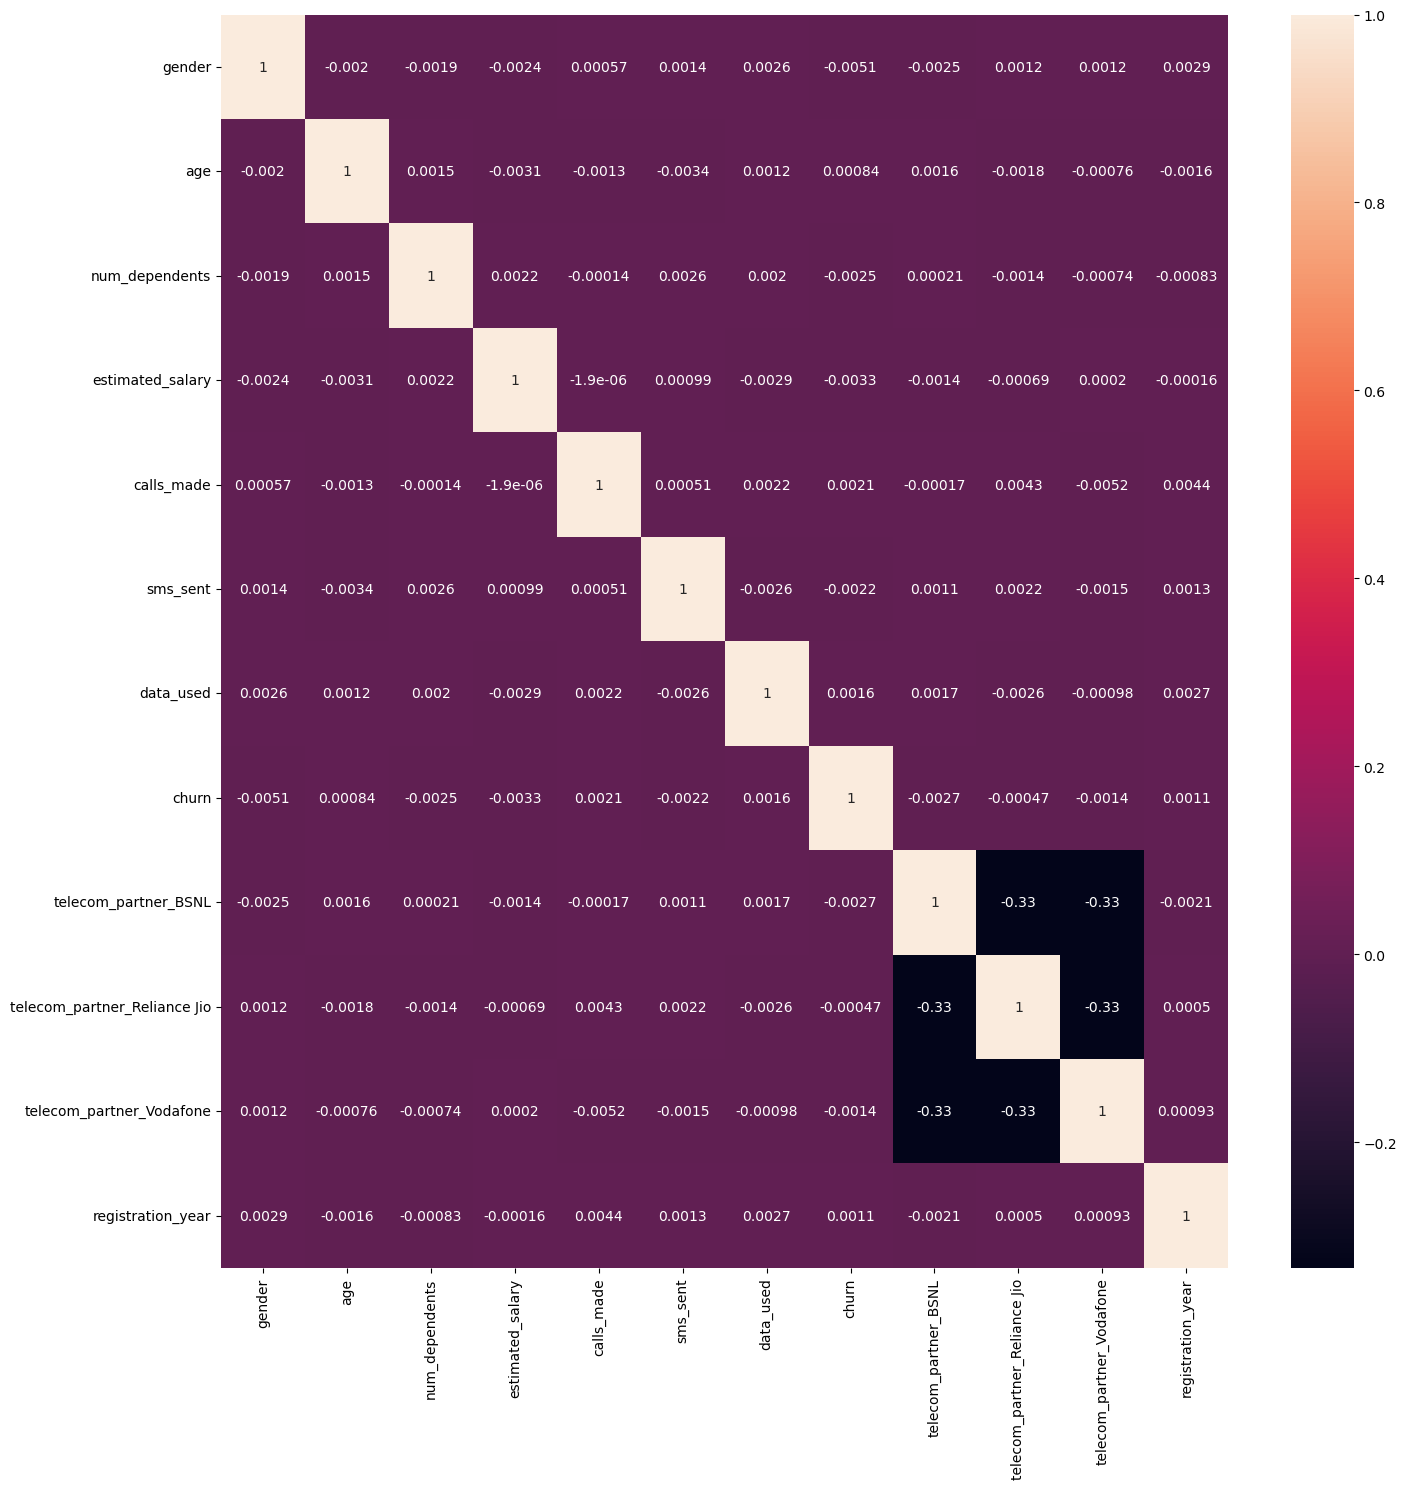

In [45]:
plt.figure(figsize=(15,15))
sns.heatmap(data.corr(),annot=True)
plt.tight_layout()
plt.show()

### Insights:-

* As we can see that most of the columns are very less correlated with the target like age,calls_made,data_used,and registration_year.
* As we are having very less columns, I'm not droping these columns. 

## Split Data into X and Y

In [46]:
# Spliting data into x and y
X = data.drop('churn',axis=1)
Y = data['churn']

In [47]:
# checking the data is balanced or not

data['churn'].value_counts()

churn
0    194726
1     48827
Name: count, dtype: int64

In [48]:
# dividing the entire data for training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.25,random_state=0)

In [49]:
x_train.shape

(182664, 11)

In [50]:
# as we can see that the data is not balanced so we need to balanced the data using SMOTE

from imblearn.over_sampling import SMOTE             # importing the SMOTE to handle the unbalanced data
sm = SMOTE()                                         # initialize the model
x_smote,y_smote = sm.fit_resample(x_train,y_train)   # fit the ddata to balanced

In [51]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_smote))

Counter({0: 146069, 1: 36595})
Counter({0: 146069, 1: 146069})


# Model Selection

## Logistic Regression

In [52]:
# importing the logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()   # Initialize the model
lr.fit(x_smote,y_smote)    # Fitting the dataset into the model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
# model prediction

lr_pred = lr.predict(x_test)
lr_pred

array([0, 0, 1, ..., 0, 0, 1], shape=(60889,))

In [54]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
lr_acc = accuracy_score(y_test,lr_pred)
lr_f1 = f1_score(y_test,lr_pred,average="weighted")


In [55]:
lr_acc

0.5899095074644024

In [56]:
lr_f1

0.6244553078034182

In [57]:
confusion_matrix(y_test,lr_pred)

array([[31594, 17063],
       [ 7907,  4325]])

In [58]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.80      0.65      0.72     48657
           1       0.20      0.35      0.26     12232

    accuracy                           0.59     60889
   macro avg       0.50      0.50      0.49     60889
weighted avg       0.68      0.59      0.62     60889



## Random Forest

In [59]:
# importing random forest classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators= 250)    # initialize the model
rf.fit(x_smote,y_smote)     # fit the data into the model

,n_estimators,250
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
## predicting

rf_pred = rf.predict(x_test)
rf_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(60889,))

In [61]:
## Checking accuraccy
rf_acc = accuracy_score(y_test,rf_pred)
rf_f1 = f1_score(y_test,rf_pred,average="weighted")

In [62]:
rf_acc

0.6930644287145461

In [63]:
rf_f1

0.6880162449906296

In [64]:
confusion_matrix(y_test,rf_pred)

array([[39819,  8838],
       [ 9851,  2381]])

In [65]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81     48657
           1       0.21      0.19      0.20     12232

    accuracy                           0.69     60889
   macro avg       0.51      0.51      0.51     60889
weighted avg       0.68      0.69      0.69     60889



### Hyperparameter tuning

In [66]:
# applied tuning on sample traing data 
x_train_sample = x_smote.sample(frac=0.25, random_state=42)
y_train_sample = y_smote.loc[x_train_sample.index]

# Define hyperparameter grid for RandomizedSearchCV 

from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(100,500,10)]   ## list comprehension for total number of estimators
max_features = ['log2','sqrt']         ## maximum number of features allowed to try in individual tree 
max_depth = [int(x) for x in np.linspace(10,100,5)]     ## maximum number of height of tree
min_samples_split = [2,5,10]        ## minimum number of samples to be present in internal node
min_samples_leaf = [1,2,5]         ## minimum number of samples to be present in a leaf node
bootstrap = [True,False]   # Sampling with replacement or not

In [81]:
# dictionary for hyperparameters
random_grid = {'n_estimators':n_estimators,'max_features':max_features,'max_depth':max_depth,
              'min_samples_split':min_samples_split,'min_samples_leaf':min_samples_leaf,'bootstrap':bootstrap}

rf_clf1 = RandomForestClassifier(random_state=39)
rf_hy = RandomizedSearchCV(estimator=rf_clf1,scoring='accuracy',param_distributions=random_grid,n_iter=10,
                           cv=2,verbose=3,random_state=49,n_jobs=1)

# estimators ---> numberr of decision tree
# scoring -----> to measure the performance
# param_distribution -----> hyperparameters values 
# n_iter ------> no.of iteration
# cv ----> total numberr of folds
# verbose --------> it will prints messages
# n_jobs -----> number of jobs means processor and -1 indicates all processor run in parallel


rf_hy.fit(x_train_sample,y_train_sample)                      ## it is used to fit training data on randomsearch cv
rf_best_params = rf_hy.best_params_                ## it is used to give best parameters
print(f"Best Parameters: {rf_best_params}")        ## printing best parameters


Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Parameters: {'n_estimators': 277, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 55, 'bootstrap': True}


In [67]:
# Building a model with the hyperparameter tuning
rf1 = RandomForestClassifier(n_estimators= 277, min_samples_split = 2, min_samples_leaf= 5, max_features= 'log2', max_depth= 55, bootstrap= True)
rf1.fit(x_smote,y_smote)

,n_estimators,277
,criterion,'gini'
,max_depth,55
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
## predicting

rf1_pred = rf1.predict(x_test)
rf1_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(60889,))

In [69]:
## Checking accuraccy
rf1_acc = accuracy_score(y_test,rf1_pred)
rf1_f1 = f1_score(y_test,rf1_pred,average="weighted")

In [70]:
rf1_acc

0.6938034784608057

In [71]:
rf1_f1

0.688561475228413

In [72]:
confusion_matrix(y_test,rf1_pred)

array([[39861,  8796],
       [ 9848,  2384]])

In [73]:
print(classification_report(y_test,rf1_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81     48657
           1       0.21      0.19      0.20     12232

    accuracy                           0.69     60889
   macro avg       0.51      0.51      0.51     60889
weighted avg       0.68      0.69      0.69     60889



## Decision Tree

In [74]:
# importing decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=47)     # initialize the model
dt.fit(x_smote,y_smote)    # fitting the data into the model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,47
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
# predicting the model
dt_pred = dt.predict(x_test)
dt_pred

array([1, 1, 0, ..., 1, 0, 0], shape=(60889,))

In [76]:
# cehcking the accuracy
dt_acc = accuracy_score(y_test,dt_pred)
dt_f1 = f1_score(y_test,dt_pred,average="weighted")

In [77]:
dt_acc

0.5918638834600667

In [78]:
dt_f1

0.6257792821524899

In [79]:
confusion_matrix(y_test,dt_pred)

array([[31776, 16881],
       [ 7970,  4262]])

In [80]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.80      0.65      0.72     48657
           1       0.20      0.35      0.26     12232

    accuracy                           0.59     60889
   macro avg       0.50      0.50      0.49     60889
weighted avg       0.68      0.59      0.63     60889



### Hyperparameter tuning

In [81]:
## crearing dictionary for hyperparameters
from sklearn.model_selection import RandomizedSearchCV
params = {'criterion':('gini','entropy'),          # Methods to measure quality of a split
         'splitter':('random','best'),             # To choose split at each node
         'max_depth':(list(range(1,30))),          # Maximum height of the tree
         'min_samples_split':[2,5,7,10],           # Minimum samples required to split an internal node
         'min_samples_leaf':list(range(1,20))}     # Minimum samples required in a leaf node

tree_clf = DecisionTreeClassifier(random_state=9)
tree_hy = RandomizedSearchCV(tree_clf,params,scoring='accuracy',n_jobs=-1,verbose=3,cv=5)       ## Initialize the GridSearchCV


# verbose=2 = show training progress in a clean, readable way.
#n_jobs = -1 =  use all CPU cores to make training faster.

tree_hy.fit(x_smote,y_smote)                    ## fit a data for hyperparameter tuning
best_params = tree_hy.best_params_             ## Best Parameters given by using hyperparameter tuning
print(f"Best Parameters: {best_params}")       ## Printing the best parameters  

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'splitter': 'random', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'entropy'}


In [82]:
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=9,min_samples_split=7,min_samples_leaf=9,splitter='random')
dt1.fit(x_smote,y_smote)

,criterion,'entropy'
,splitter,'random'
,max_depth,9
,min_samples_split,7
,min_samples_leaf,9
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [83]:
## Prediction
dt_pred1 = dt1.predict(x_test)
dt_pred1

array([0, 1, 0, ..., 0, 0, 0], shape=(60889,))

In [84]:
## checking accuracy by using hyperparameter tuning
dt1_acc = accuracy_score(y_test,dt_pred1)
dt1_acc

0.6823564190576294

In [85]:
## checking f1 score for hyperparameter tuning
dt1_f1 = f1_score(y_test,dt_pred1,average='weighted')
dt1_f1

0.6821859727459567

In [86]:
print(classification_report(y_test,dt_pred1))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     48657
           1       0.21      0.21      0.21     12232

    accuracy                           0.68     60889
   macro avg       0.50      0.50      0.50     60889
weighted avg       0.68      0.68      0.68     60889



## XGBoost

In [87]:
# importing XGBClassifier
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators = 300)      # initialize the model
xgb.fit(x_train,y_train)       # fitting the data into the model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [88]:
xgb_pred = xgb.predict(x_test)
xgb_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(60889,))

In [89]:
# checking the accuracy
xgb_acc = accuracy_score(y_test,xgb_pred)
xgb_f1 = f1_score(y_test,xgb_pred,average="weighted")

In [90]:
xgb_acc

0.7963178899308578

In [91]:
xgb_f1

0.7100842115837023

In [92]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     48657
           1       0.19      0.00      0.01     12232

    accuracy                           0.80     60889
   macro avg       0.49      0.50      0.45     60889
weighted avg       0.68      0.80      0.71     60889



### Hyperparameter tuning

In [93]:
## crearing dictionary for hyperparameters
param_grid = {
    "n_estimators": [200, 300, 400],            # total number of estimators
    "max_depth": [3, 5, 7, 9],                  # height of tree
    "learning_rate": [0.01, 0.05, 0.1, 0.2],      # learning speed
    "subsample": [0.7, 0.8, 0.9],               # fraction of training rows used for each tree
    "colsample_bytree": [0.7, 0.8, 0.9],         # fraction of features used for each tree
    "gamma": [0, 0.1, 0.3, 0.5],                # minimum loss reduction required to make a split
    "min_child_weight": [1, 3, 5]                # minimum sum of instance weight needed in a leaf
}

from sklearn.model_selection import RandomizedSearchCV

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1",     
    cv=3,
    verbose=3,
    random_state=42,
    n_jobs=1
)
# fitting the data into the hyperparameter tuning model
xgb_random.fit(x_train, y_train)

# Printing the best parameter for the model
best_params = xgb_random.best_params_             ## Best Parameters given by using hyperparameter tuning
print("Best Parameters:", best_params)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV 1/3] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.2, max_depth=9, min_child_weight=5, n_estimators=300, subsample=0.9;, score=0.027 total time=   1.6s
[CV 2/3] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.2, max_depth=9, min_child_weight=5, n_estimators=300, subsample=0.9;, score=0.028 total time=   2.0s
[CV 3/3] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.2, max_depth=9, min_child_weight=5, n_estimators=300, subsample=0.9;, score=0.025 total time=   1.6s
[CV 1/3] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=9, min_child_weight=5, n_estimators=200, subsample=0.8;, score=0.001 total time=   1.1s
[CV 2/3] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=9, min_child_weight=5, n_estimators=200, subsample=0.8;, score=0.002 total time=   1.1s
[CV 3/3] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=9, min_child_weight=5, n_estimators=200, subsample=0.8;

In [94]:
# building the new model with the best hyparameters
xgb1 = XGBClassifier(n_estimators=400,subsample=0.7,min_child_weights = 3, max_depth = 9,learning_rate = 0.2,gamma=0.5,colsample_bytree=0.8)
xgb1.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [95]:
# predicting
xgb1_pred = xgb1.predict(x_test)
xgb1_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(60889,))

In [96]:
xgb1_acc = accuracy_score(y_test,xgb1_pred)
xgb1_f1 = f1_score(y_test,xgb1_pred,average = 'weighted')

In [97]:
xgb1_acc

0.7834584243459409

In [98]:
xgb1_f1

0.7097401063214159

In [99]:
print(classification_report(y_test,xgb1_pred))

              precision    recall  f1-score   support

           0       0.80      0.97      0.88     48657
           1       0.18      0.02      0.04     12232

    accuracy                           0.78     60889
   macro avg       0.49      0.50      0.46     60889
weighted avg       0.68      0.78      0.71     60889



## ANN

In [100]:
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

# Scale original train data
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled  = scaler.transform(x_test)

# Apply SMOTE on scaled train data
smote = SMOTE(random_state=42)

X_smote_scaled, y_smote = smote.fit_resample(X_train_scaled, y_train)


In [106]:
# Import MLPClassifier for building the Artificial Neural Network (ANN) model
from sklearn.neural_network import MLPClassifier

# Initialize the ANN model with optimized hyperparameters
ann = MLPClassifier(

    hidden_layer_sizes=(128, 64),  
    # Defines the architecture of the neural network:
    # 1st hidden layer → 128 neurons
    # 2nd hidden layer → 64 neurons
    learning_rate_init=0.001,                 # Initial learning rate for weight updates

    max_iter=500,                             # Maximum number of training iterations (epochs)
    early_stopping=True,                      # Stops training automatically when validation score stops improving
    validation_fraction=0.1,                  # Uses 10% of the training data as validation data for early stopping
    n_iter_no_change=10,                      # Training will stop if validation score does not improve for 10 consecutive iterations
    learning_rate='adaptive',                  # Reduces the learning rate when the model stops improving
    random_state=0  
)

# Train the ANN model on SMOTE-balanced and scaled training data
ann.fit(X_smote_scaled, y_smote)


,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,0


In [107]:
# Prediction

ann_pred = ann.predict(x_test)
ann_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(60889,))

In [108]:
# train data prediction
ann_train_pred = ann.predict(x_train)

In [109]:
# checking accuracy and f1 score
ann_acc = accuracy_score(y_test,ann_pred)
ann_f1 = f1_score(y_test,ann_pred,average='weighted')

In [110]:
ann_acc

0.7991098556389495

In [111]:
ann_f1

0.7098805660786222

In [112]:
print(classification_report(y_test,ann_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     48657
           1       0.00      0.00      0.00     12232

    accuracy                           0.80     60889
   macro avg       0.40      0.50      0.44     60889
weighted avg       0.64      0.80      0.71     60889



## KNN

In [113]:
# importing K Nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)     # initialize the model with 5 nearest neighbors
knn.fit(X_smote_scaled,y_smote)       # fitting the data into the model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [114]:
# Predicting the model

knn_pred = knn.predict(x_test)
knn_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(60889,))

In [115]:
knn_acc = accuracy_score(y_test,knn_pred)
knn_f1 = f1_score(y_test,knn_pred,average="weighted")

In [116]:
knn_acc

0.7989127757066137

In [117]:
knn_f1

0.7100012642926146

In [118]:
print(classification_report(y_test,knn_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     48657
           1       0.27      0.00      0.00     12232

    accuracy                           0.80     60889
   macro avg       0.53      0.50      0.44     60889
weighted avg       0.69      0.80      0.71     60889



In [119]:
# checking the lowest error rate at how many neighbors
error_rate = []     # storing all error rate 

for i in range(1,10): # checking 1 to 10 neighors
    KNN = KNeighborsClassifier(n_neighbors=i)    # inintialize the model
    KNN.fit(X_smote_scaled,y_smote)      # fit the data into the model
    KNN_pred = KNN.predict(x_test)     # predicting
    error_rate.append(np.mean(KNN_pred != y_test))    # appending the error in error rate 

In [120]:
# printing the all the error
error_rate

[np.float64(0.20089014436105043),
 np.float64(0.20089014436105043),
 np.float64(0.20197408398889782),
 np.float64(0.20097226099952373),
 np.float64(0.20108722429338632),
 np.float64(0.20089014436105043),
 np.float64(0.2009886843272184),
 np.float64(0.20089014436105043),
 np.float64(0.20172773407347797)]

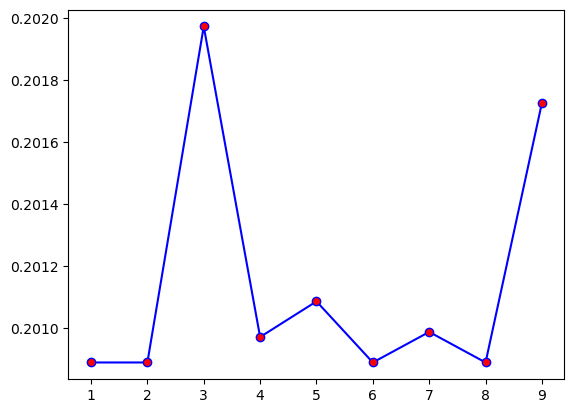

In [121]:
# plotting the error and check at which neighbor the error is very low
plt.plot(range(1,10),error_rate,color='blue',marker='o',markerfacecolor='red')

In [128]:
# as wee can see that that at 3 neigbors the error is low 
# importing K Nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
knn1 = KNeighborsClassifier(n_neighbors = 7)     # initialize the model with 5 nearest neighbors
knn1.fit(X_smote_scaled,y_smote)       # fitting the data into the model

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [129]:
knn1_pred = knn1.predict(x_test)
knn1_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(60889,))

In [130]:
knn1_acc = accuracy_score(y_test,knn1_pred)
knn1_f1 = f1_score(y_test,knn1_pred,average='weighted')

In [131]:
knn1_acc

0.7990113156727816

In [132]:
knn1_f1

0.7098631028410414

In [133]:
print(classification_report(y_test,knn1_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     48657
           1       0.12      0.00      0.00     12232

    accuracy                           0.80     60889
   macro avg       0.46      0.50      0.44     60889
weighted avg       0.66      0.80      0.71     60889



# Model Comparision Report

In [145]:
# creating model comparison report using DataFrame
score = pd.DataFrame({"Models":["LogisticRegression","RandomForestClassifier","KNeighborsClassifier","DecisionTreeClassifier","ANN"],
                     "Accuracy":[lr_acc*100,rf_acc*100,knn_acc*100,dt_acc*100,ann_acc*100],
                      "f1_score":[lr_f1*100,rf_f1*100,knn_f1*100,dt_f1*100,ann_f1*100],
                     "With Hyperparameter Tunning":["-",rf1_acc*100,knn1_acc*100,dt1_acc*100,'-'],
                     })

In [146]:
score

,Models,Accuracy,f1_score,With Hyperparameter Tunning
0,LogisticRegression,58.990951,62.445531,-
1,RandomForestClassifier,69.306443,68.801624,69.380348
2,KNeighborsClassifier,79.891278,71.000126,79.901132
3,DecisionTreeClassifier,59.186388,62.577928,68.235642
4,ANN,79.910986,70.988057,-


# Model Comparision Report

In this project, **five machine learning algorithms — Logistic Regression, Random Forest Classifier, K-Nearest Neighbors (KNN), Decision Tree Classifier, and Artificial Neural Network (ANN)** — were applied to predict customer churn and their performances were compared using **accuracy** and **F1-score**. **Logistic Regression** and **Decision Tree** produced lower accuracy (around **59%**), showing limited ability to capture complex patterns in the dataset. **Random Forest** improved the performance and achieved about **69.38% accuracy after hyperparameter tuning**, which highlights the impact of model optimization. The **K-Nearest Neighbors (79.90%)** and **ANN (79.91%)** models delivered the **highest accuracy with strong F1-scores**, indicating better and more balanced predictions for both churn and non-churn customers. Among all the models, **ANN achieved the best overall performance**, closely followed by **KNN**, making them the **most suitable algorithms for this churn prediction task**.


# Data Analysis Report


In this project, the telecom churn dataset was first imported and explored to understand its structure, data types, and the distribution of the target variable. Initial analysis included checking the number of rows and columns, identifying categorical and numerical features, and understanding the churn imbalance in the dataset. Missing values were handled carefully, and unnecessary columns that did not contribute to prediction were removed. Data cleaning steps such as correcting data types, handling blank spaces, and removing duplicates helped in improving the overall data quality before moving to the modeling phase.

During the **exploratory data analysis (EDA)** stage, the relationship between independent features and the churn column was examined using visualizations and summary statistics. This helped in identifying important factors influencing customer churn, such as tenure, monthly charges, and service-related features. Categorical variables were converted into numerical form using encoding techniques so that machine learning models could process them. Feature selection was also performed to keep only the most relevant variables for model training.

The dataset was then split into **training and testing sets** to ensure proper model evaluation on unseen data. Since the target variable was highly imbalanced, **SMOTE (Synthetic Minority Oversampling Technique)** was applied only on the training data to create a balanced dataset. This step was important to help the models learn the churn patterns properly instead of being biased toward the majority class. For models like KNN and ANN that are sensitive to feature scale, **feature scaling using MinMaxScaler** was performed to bring all the values into the same range, which improves convergence speed and distance calculations.

After preprocessing, multiple machine learning models were applied, including **Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, and Artificial Neural Network (ANN)**. Hyperparameter tuning was performed for selected models such as Random Forest to improve their performance. Each model was trained on the processed training data and evaluated on the test data using performance metrics like accuracy and F1-score to ensure a fair comparison.

Overall, the project followed a proper machine learning pipeline that included **data cleaning, encoding, train-test splitting, handling class imbalance with SMOTE, feature scaling, model building, and hyperparameter tuning**. These steps ensured that the data was in the right format for training and that the models were able to learn meaningful patterns for churn prediction. The structured preprocessing and analysis played a key role in achieving better and more reliable model performance.


# Challenges Faced During the Project

One of the main challenges in this project was handling the **large dataset size**, which contains **243,553 rows and 14 columns**. Because of this high volume of data, the preprocessing steps such as encoding, scaling, and applying SMOTE took a noticeable amount of time to execute. The large size also increased the computational cost during model training and evaluation, especially when multiple algorithms were applied and compared.

Another major difficulty was during the **model building phase**, where training time became very high. Algorithms like Random Forest, K-Nearest Neighbors, and Artificial Neural Network required significant time to fit the data, and this became even more time-consuming when hyperparameter tuning was performed.

Handling the **imbalanced target variable** was also a challenge. Before applying SMOTE, the models were biased toward the majority class and were not able to predict churn customers properly. Applying SMOTE only on the training data required careful implementation to avoid data leakage and to maintain the correct machine learning pipeline.

Another challenge was ensuring the correct order of preprocessing steps. The process involved **train–test splitting, feature scaling, and then applying SMOTE**, and maintaining this sequence consistently for different models required careful handling of the data at each stage. Additionally, scaling had to be applied separately for models like KNN and ANN, which increased the complexity of the workflow.

Comparing multiple models and tracking their performance using **accuracy and F1-score** was also time-intensive because each model had to be trained on the processed dataset and evaluated on the test data. Hyperparameter tuning for Random Forest further increased the total execution time but was necessary to improve the model performance.

Overall, the key challenges in this project were the **large dataset size, high training time during model building, handling class imbalance using SMOTE, maintaining the correct preprocessing pipeline, and computational cost during hyperparameter tuning and model comparison**.


                                                                --DONE--